# 📊 Analyse financière d'une entreprise — Projet Business Intelligence

**Auteur :** Cheikh Sall · **Dataset :** Microsoft *Financial Sample* (700 transactions, 2013-2014)

Ce notebook couvre l'intégralité de la chaîne analytique :
1. Chargement & compréhension des données
2. Nettoyage et contrôle qualité
3. Création de variables financières calculées
4. Analyse exploratoire & KPI financiers
5. Compte de résultat simplifié
6. Prévisions (moyenne mobile, régression linéaire, SARIMA)
7. Recommandations business

Les fichiers produits (`financial_data_clean.csv`, figures) alimentent les scripts SQL, le dashboard Power BI et le rapport PDF.

## 1. Imports et configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titleweight": "bold",
                     "figure.autolayout": True, "axes.grid": True})

# Chemins du projet
PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR   = PROJECT / "data"
FIG_DIR    = PROJECT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    plt.savefig(FIG_DIR / name, dpi=120, bbox_inches="tight")

EUR = lambda x: f"{x:,.0f} $".replace(",", " ")
print("Environnement prêt. Projet :", PROJECT)

Environnement prêt. Projet : C:\projet\BI4\financial-analysis-dashboard


## 2. Chargement des données

In [2]:
raw = pd.read_excel(DATA_DIR / "Financial_Sample.xlsx")
print("Dimensions :", raw.shape)
raw.head()

Dimensions : (700, 16)


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,NaN,1618.5,3,20,32370.0,0.0,32370.0,16185.0,16185.0,2014-01-01,1,January,2014
1,Government,Germany,Carretera,NaN,1321.0,3,20,26420.0,0.0,26420.0,13210.0,13210.0,2014-01-01,1,January,2014
2,Midmarket,France,Carretera,NaN,2178.0,3,15,32670.0,0.0,32670.0,21780.0,10890.0,2014-06-01,6,June,2014
3,Midmarket,Germany,Carretera,NaN,888.0,3,15,13320.0,0.0,13320.0,8880.0,4440.0,2014-06-01,6,June,2014
4,Midmarket,Mexico,Carretera,NaN,2470.0,3,15,37050.0,0.0,37050.0,24700.0,12350.0,2014-06-01,6,June,2014


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              700 non-null    object        
 1   Country              700 non-null    object        
 2   Product              700 non-null    object        
 3   Discount Band        647 non-null    object        
 4   Units Sold           700 non-null    float64       
 5   Manufacturing Price  700 non-null    int64         
 6   Sale Price           700 non-null    int64         
 7   Gross Sales          700 non-null    float64       
 8   Discounts            700 non-null    float64       
 9    Sales               700 non-null    float64       
 10  COGS                 700 non-null    float64       
 11  Profit               700 non-null    float64       
 12  Date                 700 non-null    datetime64[ns]
 13  Month Number         700 non-null  

## 3. Compréhension des données

| Variable | Description | Type |
|---|---|---|
| `Segment` | Segment de marché (Government, Enterprise, …) | Catégoriel |
| `Country` | Pays de vente | Catégoriel |
| `Product` | Produit vendu | Catégoriel |
| `Discount Band` | Niveau de remise (None / Low / Medium / High) | Catégoriel |
| `Units Sold` | Quantité vendue | Numérique |
| `Manufacturing Price` | Coût unitaire de fabrication | Numérique |
| `Sale Price` | Prix de vente unitaire | Numérique |
| `Gross Sales` | Ventes brutes = Units Sold × Sale Price | Numérique |
| `Discounts` | Montant des remises | Numérique |
| `Sales` | **Chiffre d'affaires net** = Gross Sales − Discounts | Numérique |
| `COGS` | Coût des ventes (Cost of Goods Sold) | Numérique |
| `Profit` | Profit = Sales − COGS | Numérique |
| `Date` | Date de la transaction | Date |

**Indicateurs financiers visés :** Chiffre d'affaires (Sales), Coût des ventes (COGS),
Marge brute (Profit), Taux de marge, Rentabilité (ROI).

## 4. Nettoyage des données

In [4]:
df = raw.copy()

# 4.1 Normalisation des noms de colonnes (le dataset contient des espaces parasites, ex. ' Sales')
df.columns = (df.columns.str.strip()
                        .str.replace(" ", "_")
                        .str.replace(r"[()]", "", regex=True))
print(list(df.columns))

['Segment', 'Country', 'Product', 'Discount_Band', 'Units_Sold', 'Manufacturing_Price', 'Sale_Price', 'Gross_Sales', 'Discounts', 'Sales', 'COGS', 'Profit', 'Date', 'Month_Number', 'Month_Name', 'Year']


In [5]:
# 4.2 Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isna().sum()[df.isna().sum() > 0])

# 'Discount_Band' est NaN quand aucune remise n'est appliquée -> 'None'
df["Discount_Band"] = df["Discount_Band"].fillna("None")
print("\nAprès traitement :", int(df.isna().sum().sum()), "valeur(s) manquante(s)")

Valeurs manquantes par colonne :
Discount_Band    53
dtype: int64

Après traitement : 0 valeur(s) manquante(s)


In [6]:
# 4.3 Doublons
dups = df.duplicated().sum()
print(f"Doublons détectés : {dups}")
df = df.drop_duplicates().reset_index(drop=True)

Doublons détectés : 0


In [7]:
# 4.4 Types de variables
df["Date"] = pd.to_datetime(df["Date"])
cat_cols = ["Segment", "Country", "Product", "Discount_Band", "Month_Name"]
for c in cat_cols:
    df[c] = df[c].astype("category")
df["Units_Sold"] = df["Units_Sold"].astype(float)
df.dtypes

Segment                      category
Country                      category
Product                      category
Discount_Band                category
Units_Sold                    float64
Manufacturing_Price             int64
Sale_Price                      int64
Gross_Sales                   float64
Discounts                     float64
Sales                         float64
COGS                          float64
Profit                        float64
Date                   datetime64[ns]
Month_Number                    int64
Month_Name                   category
Year                            int64
dtype: object

In [8]:
# 4.5 Contrôle de cohérence : Sales doit ~ Gross_Sales - Discounts ; Profit ~ Sales - COGS
chk_sales  = (df["Gross_Sales"] - df["Discounts"] - df["Sales"]).abs().max()
chk_profit = (df["Sales"] - df["COGS"] - df["Profit"]).abs().max()
print(f"Écart max recalcul Sales  : {chk_sales:.4f}")
print(f"Écart max recalcul Profit : {chk_profit:.4f}")
print("=> Les identités comptables sont respectées." if max(chk_sales, chk_profit) < 1 else "=> Anomalie détectée !")

Écart max recalcul Sales  : 0.0000
Écart max recalcul Profit : 0.0000
=> Les identités comptables sont respectées.


Sales       :  53 points hors [-351,796 ; 628,802]
Profit      : 103 points hors [-26,978 ; 52,446]
Units_Sold  :   4 points hors [-1,081 ; 4,215]


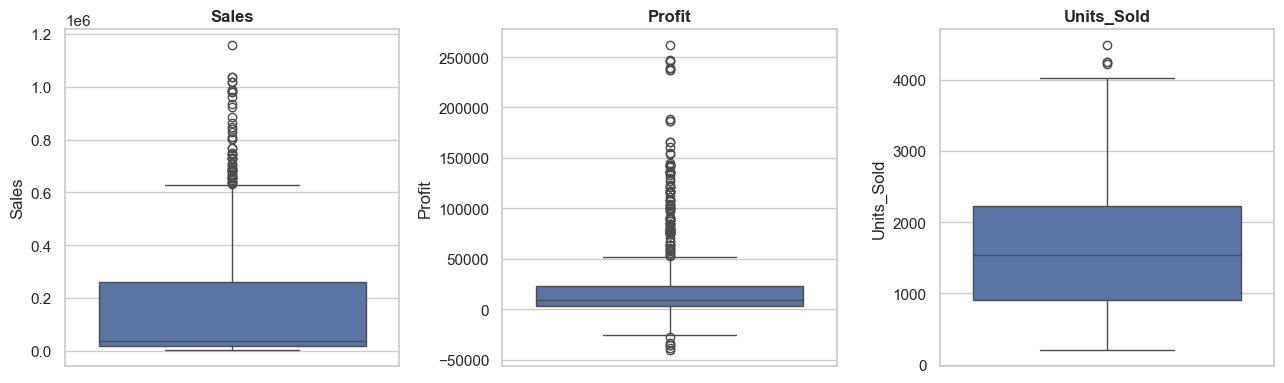

Remarque : les profits négatifs proviennent de remises élevées (Discount Band = High) ; ce sont des cas métier réels, conservés volontairement.


In [9]:
# 4.6 Détection de valeurs aberrantes (méthode IQR) sur Profit et Sales
def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((s < low) | (s > high)).sum(), low, high

for col in ["Sales", "Profit", "Units_Sold"]:
    n, low, high = iqr_outliers(df[col])
    print(f"{col:12s}: {n:3d} points hors [{low:,.0f} ; {high:,.0f}]")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["Sales", "Profit", "Units_Sold"]):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0"); ax.set_title(col)
save_fig("01_outliers_boxplot.png"); plt.show()
print("Remarque : les profits négatifs proviennent de remises élevées (Discount Band = High) ; "
      "ce sont des cas métier réels, conservés volontairement.")

## 4.7 Variables financières calculées

In [10]:
df["Profit_Margin_%"] = np.where(df["Sales"] > 0, df["Profit"] / df["Sales"] * 100, 0)
df["Cost_Ratio_%"]    = np.where(df["Sales"] > 0, df["COGS"]   / df["Sales"] * 100, 0)
df["Discount_Rate_%"] = np.where(df["Gross_Sales"] > 0, df["Discounts"] / df["Gross_Sales"] * 100, 0)
df["ROI_%"]           = np.where(df["COGS"] > 0, df["Profit"]  / df["COGS"]  * 100, 0)
df["Year_Month"]      = df["Date"].dt.to_period("M").astype(str)

df[["Sales", "COGS", "Profit", "Profit_Margin_%", "Cost_Ratio_%", "Discount_Rate_%", "ROI_%"]].describe().round(2)

,Sales,COGS,Profit,Profit_Margin_%,Cost_Ratio_%,Discount_Rate_%,ROI_%
count,700.00,700.00,700.00,700.00,700.00,700.00,700.00
mean,169609.07,145475.21,24133.86,27.90,72.10,7.33,65.33
std,236726.35,203865.51,42760.63,23.42,23.42,4.60,88.52
min,1655.08,918.00,-40617.50,-12.94,25.00,0.00,-11.46
25%,15928.00,7490.00,2805.96,13.05,56.82,3.00,15.01
50%,35540.20,22506.25,9242.20,23.37,76.63,7.00,30.50
75%,261077.50,245607.50,22662.00,43.18,86.95,11.00,76.00
max,1159200.00,950625.00,262200.00,75.00,112.94,15.00,300.00


In [11]:
# Sauvegarde du dataset nettoyé (utilisé par SQL et Power BI)
clean_path = DATA_DIR / "financial_data_clean.csv"
df.to_csv(clean_path, index=False, encoding="utf-8-sig")
print("Données nettoyées enregistrées :", clean_path, "|", df.shape)

Données nettoyées enregistrées : C:\projet\BI4\financial-analysis-dashboard\data\financial_data_clean.csv | (700, 21)


## 5. Analyse exploratoire & KPI financiers

In [12]:
total_sales   = df["Sales"].sum()
total_cogs    = df["COGS"].sum()
total_disc    = df["Discounts"].sum()
total_profit  = df["Profit"].sum()
avg_margin    = total_profit / total_sales * 100
roi_global    = total_profit / total_cogs * 100
units         = df["Units_Sold"].sum()

kpis = pd.DataFrame({
    "KPI": ["Chiffre d'affaires (Sales)", "Coût des ventes (COGS)", "Remises totales",
            "Profit total", "Marge moyenne", "ROI global", "Unités vendues"],
    "Valeur": [EUR(total_sales), EUR(total_cogs), EUR(total_disc), EUR(total_profit),
               f"{avg_margin:.1f} %", f"{roi_global:.1f} %", f"{units:,.0f}".replace(',', ' ')]
})
kpis

,KPI,Valeur
0,Chiffre d'affaires (Sales),118 726 350 $
1,Coût des ventes (COGS),101 832 648 $
2,Remises totales,9 205 248 $
3,Profit total,16 893 702 $
4,Marge moyenne,14.2 %
5,ROI global,16.6 %
6,Unités vendues,1 125 806


### 5.1 Évolution mensuelle du chiffre d'affaires et du profit

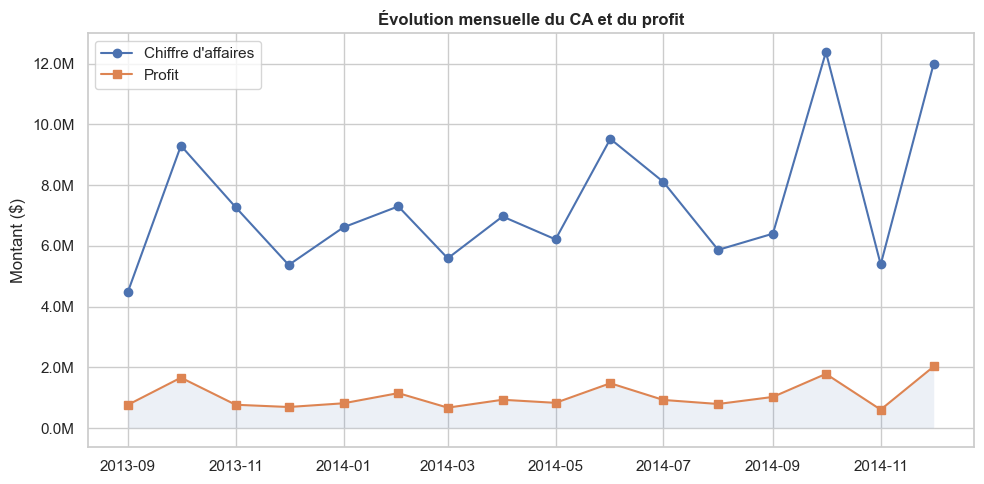

,Year_Month,Sales,Profit,COGS,Sales_Growth_%
0,2013-09-01,4484000.0,763603.0,3720397.0,NaN
1,2013-10-01,9295611.1,1657795.1,7637816.0,107.3
2,2013-11-01,7267203.3,765502.3,6501701.0,-21.8
3,2013-12-01,5368441.1,691564.1,4676877.0,-26.1
4,2014-01-01,6607761.7,814028.7,5793733.0,23.1
5,2014-02-01,7297531.4,1148547.4,6148984.0,10.4
6,2014-03-01,5586859.9,669866.9,4916993.0,-23.4
7,2014-04-01,6964775.1,929984.6,6034790.5,24.7
8,2014-05-01,6210211.1,828640.1,5381571.0,-10.8
9,2014-06-01,9518893.8,1473753.8,8045140.0,53.3


In [13]:
monthly = (df.groupby("Year_Month")
             .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), COGS=("COGS", "sum"))
             .reset_index())
monthly["Year_Month"] = pd.PeriodIndex(monthly["Year_Month"], freq="M").to_timestamp()
monthly = monthly.sort_values("Year_Month")
monthly["Sales_Growth_%"] = monthly["Sales"].pct_change() * 100

fig, ax = plt.subplots()
ax.plot(monthly["Year_Month"], monthly["Sales"], marker="o", label="Chiffre d'affaires")
ax.plot(monthly["Year_Month"], monthly["Profit"], marker="s", label="Profit")
ax.fill_between(monthly["Year_Month"], monthly["Profit"], alpha=.1)
ax.set_title("Évolution mensuelle du CA et du profit")
ax.set_ylabel("Montant ($)"); ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
save_fig("02_monthly_evolution.png"); plt.show()
monthly.round(1)

### 5.2 Performance par produit, segment et pays

In [14]:
def by_dim(dim):
    g = (df.groupby(dim, observed=True)
           .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Units=("Units_Sold", "sum"))
           .assign(Margin_pct=lambda d: d["Profit"] / d["Sales"] * 100)
           .sort_values("Profit", ascending=False).round(1))
    return g

by_product = by_dim("Product"); by_segment = by_dim("Segment"); by_country = by_dim("Country")
print("=== Par PRODUIT ==="); display(by_product)
print("=== Par SEGMENT ==="); display(by_segment)
print("=== Par PAYS ==="); display(by_country)

=== Par PRODUIT ===


,Sales,Profit,Units,Margin_pct
Product,,,,
Paseo,33011144.0,4797438.0,338239.5,14.5
VTT,20511921.0,3034608.0,168783.0,14.8
Amarilla,17747116.1,2814104.1,155315.0,15.9
Velo,18250059.5,2305992.5,162424.5,12.6
Montana,15390801.9,2114754.9,154198.0,13.7
Carretera,13815307.9,1826804.9,146846.0,13.2


=== Par SEGMENT ===


,Sales,Profit,Units,Margin_pct
Segment,,,,
Government,52504260.7,11388173.2,470673.5,21.7
Small Business,42427918.5,4143168.5,153139.0,9.8
Channel Partners,1800593.6,1316803.1,161263.5,73.1
Midmarket,2381883.1,660103.1,172178.0,27.7
Enterprise,19611694.4,-614545.6,168552.0,-3.1


=== Par PAYS ===


,Sales,Profit,Units,Margin_pct
Country,,,,
France,24354172.3,3781020.8,240931.0,15.5
Germany,23505340.8,3680388.8,201494.0,15.7
Canada,24887654.9,3529228.9,247428.5,14.2
United States of America,25029830.2,2995540.7,232627.5,12.0
Mexico,20949352.1,2907523.1,203325.0,13.9


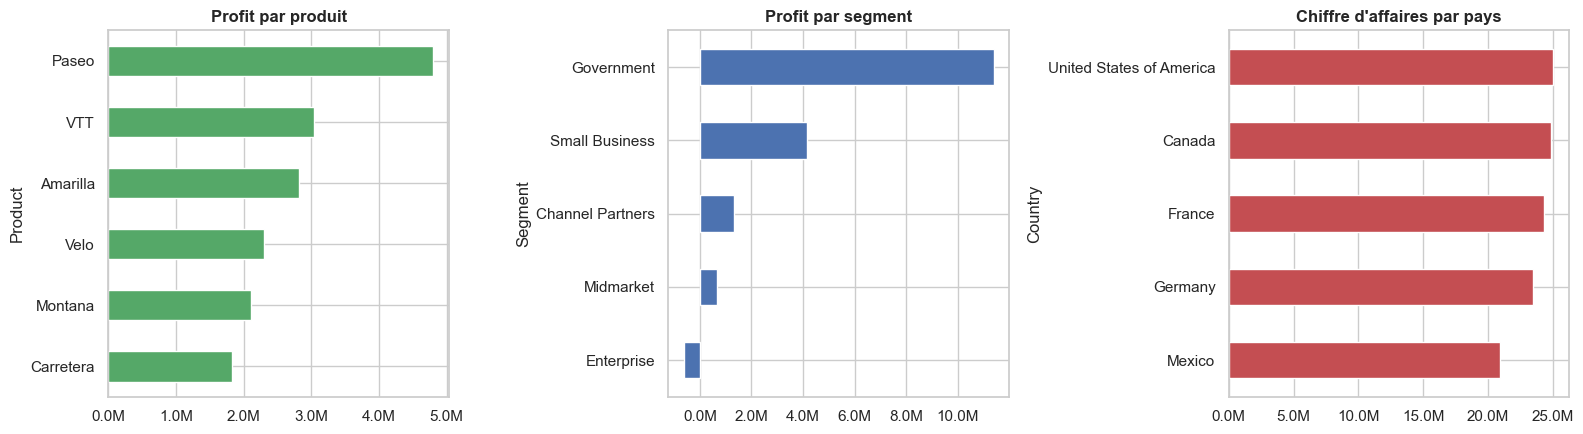

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
by_product.sort_values("Profit").plot.barh(y="Profit", ax=axes[0], color="#55A868", legend=False)
axes[0].set_title("Profit par produit")
by_segment.sort_values("Profit").plot.barh(y="Profit", ax=axes[1], color="#4C72B0", legend=False)
axes[1].set_title("Profit par segment")
by_country.sort_values("Sales").plot.barh(y="Sales", ax=axes[2], color="#C44E52", legend=False)
axes[2].set_title("Chiffre d'affaires par pays")
for ax in axes:
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
save_fig("03_performance_dimensions.png"); plt.show()

### 5.3 Analyse des marges et de l'impact des remises

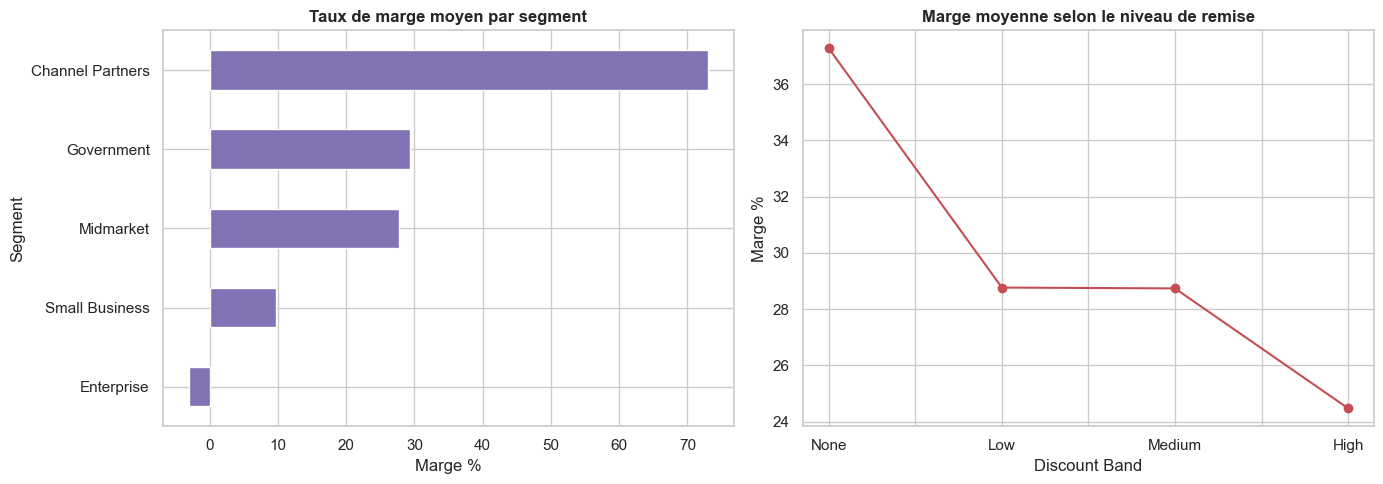

,Marge,CA
Discount_Band,,
None,37.3,7943654.0
Low,28.8,34629778.7
Medium,28.7,38780430.8
High,24.5,37372486.7


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Marge par segment
seg_margin = df.groupby("Segment", observed=True)["Profit_Margin_%"].mean().sort_values()
seg_margin.plot.barh(ax=axes[0], color="#8172B3")
axes[0].set_title("Taux de marge moyen par segment"); axes[0].set_xlabel("Marge %")

# Impact des remises sur la marge
disc = (df.groupby("Discount_Band", observed=True)
          .agg(Marge=("Profit_Margin_%", "mean"), CA=("Sales", "sum"))
          .reindex(["None", "Low", "Medium", "High"]))
disc["Marge"].plot(marker="o", ax=axes[1], color="#C44E52")
axes[1].set_title("Marge moyenne selon le niveau de remise")
axes[1].set_ylabel("Marge %"); axes[1].set_xlabel("Discount Band")
save_fig("04_margin_discount.png"); plt.show()
disc.round(1)

## 6. Compte de résultat simplifié (Income Statement)

In [17]:
income_statement = pd.DataFrame({
    "Poste": ["Ventes brutes (Gross Sales)", "(-) Remises commerciales",
              "= Chiffre d'affaires net (Sales)", "(-) Coût des ventes (COGS)",
              "= Marge brute / Profit net", "Taux de marge nette"],
    "Montant": [df['Gross_Sales'].sum(), -df['Discounts'].sum(), total_sales,
                -total_cogs, total_profit, None]
})
income_statement["Affichage"] = income_statement["Montant"].apply(
    lambda v: EUR(v) if pd.notna(v) else f"{avg_margin:.1f} %")
income_statement[["Poste", "Affichage"]]

,Poste,Affichage
0,Ventes brutes (Gross Sales),127 931 598 $
1,(-) Remises commerciales,-9 205 248 $
2,= Chiffre d'affaires net (Sales),118 726 350 $
3,(-) Coût des ventes (COGS),-101 832 648 $
4,= Marge brute / Profit net,16 893 702 $
5,Taux de marge nette,14.2 %


## 7. Prévisions financières (Forecasting)

Série mensuelle du chiffre d'affaires (16 mois). On compare trois approches sur un
*hold-out* des 4 derniers mois : **moyenne mobile**, **régression linéaire** et **SARIMA**.
Métriques : MAE et RMSE (plus c'est bas, mieux c'est).

> ⚠️ Avec seulement 16 points, les prévisions sont illustratives : l'objectif est de
> démontrer la méthodologie de comparaison de modèles.

In [18]:
ts = monthly.set_index("Year_Month")["Sales"].asfreq("MS")
h = 4                          # horizon de test
train, test = ts.iloc[:-h], ts.iloc[-h:]
print(f"Train : {len(train)} mois | Test : {len(test)} mois")

results = {}

# --- 1) Moyenne mobile (fenêtre 3) : la dernière moyenne est reportée ---
ma_value = train.rolling(3).mean().iloc[-1]
pred_ma = pd.Series(ma_value, index=test.index)
results["Moyenne mobile (3)"] = pred_ma

# --- 2) Régression linéaire sur le temps ---
X_train = np.arange(len(train)).reshape(-1, 1)
lr = LinearRegression().fit(X_train, train.values)
X_test = np.arange(len(train), len(train) + h).reshape(-1, 1)
pred_lr = pd.Series(lr.predict(X_test), index=test.index)
results["Régression linéaire"] = pred_lr

# --- 3) SARIMA (saisonnalité 12 indisponible sur 12 mois -> ordre simple) ---
sar = SARIMAX(train, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0),
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
pred_sar = sar.forecast(h); pred_sar.index = test.index
results["SARIMA(1,1,1)"] = pred_sar

# --- Comparaison ---
scores = pd.DataFrame({
    name: {"MAE": mean_absolute_error(test, pred),
           "RMSE": np.sqrt(mean_squared_error(test, pred))}
    for name, pred in results.items()
}).T.round(0)
scores = scores.sort_values("RMSE")
print(scores)
best_model = scores.index[0]
print(f"\n=> Meilleur modèle (RMSE le plus bas) : {best_model}")

Train : 12 mois | Test : 4 mois
                           MAE       RMSE
Moyenne mobile (3)   3147924.0  3394306.0
Régression linéaire  3106344.0  3477169.0
SARIMA(1,1,1)        3210122.0  3723451.0

=> Meilleur modèle (RMSE le plus bas) : Moyenne mobile (3)


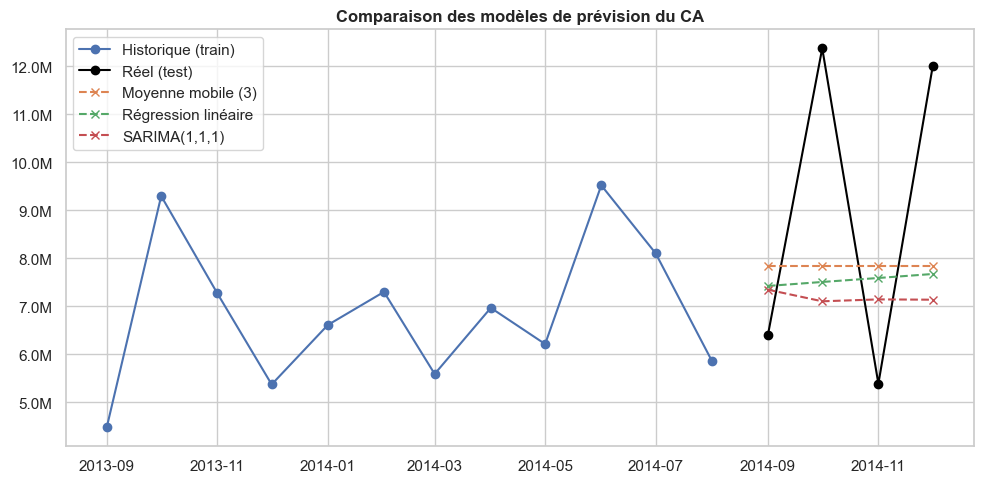

In [19]:
fig, ax = plt.subplots()
ax.plot(train.index, train.values, marker="o", label="Historique (train)")
ax.plot(test.index, test.values, marker="o", color="black", label="Réel (test)")
for name, pred in results.items():
    ax.plot(pred.index, pred.values, marker="x", linestyle="--", label=name)
ax.set_title("Comparaison des modèles de prévision du CA")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend(); save_fig("05_forecast_comparison.png"); plt.show()

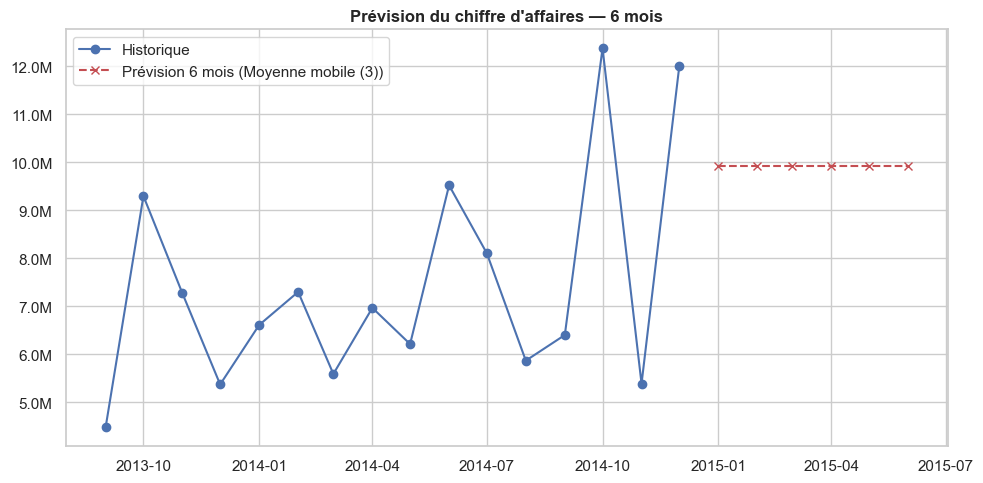

,Mois,CA_prévu
0,2015-01-01,9919607.0
1,2015-02-01,9919607.0
2,2015-03-01,9919607.0
3,2015-04-01,9919607.0
4,2015-05-01,9919607.0
5,2015-06-01,9919607.0


In [20]:
# Prévision des 6 prochains mois avec le meilleur modèle ré-entraîné sur toute la série
future_h = 6
if best_model.startswith("SARIMA"):
    final = SARIMAX(ts, order=(1, 1, 1), enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)
    fc = final.get_forecast(future_h)
    future = fc.predicted_mean
    ci = fc.conf_int()
elif best_model.startswith("Régression"):
    lr_full = LinearRegression().fit(np.arange(len(ts)).reshape(-1, 1), ts.values)
    idx = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(), periods=future_h, freq="MS")
    future = pd.Series(lr_full.predict(np.arange(len(ts), len(ts)+future_h).reshape(-1, 1)), index=idx)
    ci = None
else:
    idx = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(), periods=future_h, freq="MS")
    future = pd.Series(ts.rolling(3).mean().iloc[-1], index=idx); ci = None

fig, ax = plt.subplots()
ax.plot(ts.index, ts.values, marker="o", label="Historique")
ax.plot(future.index, future.values, marker="x", linestyle="--", color="#C44E52",
        label=f"Prévision 6 mois ({best_model})")
if ci is not None:
    ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="#C44E52", alpha=.15, label="IC 95%")
ax.set_title("Prévision du chiffre d'affaires — 6 mois")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend(); save_fig("06_forecast_future.png"); plt.show()

future_df = future.rename("CA_prévu").reset_index().rename(columns={"index": "Mois"})
future_df["CA_prévu"] = future_df["CA_prévu"].round(0)
future_df.to_csv(DATA_DIR / "forecast_6m.csv", index=False, encoding="utf-8-sig")
future_df

## 8. Recommandations business

Sur la base de l'analyse :

1. **Développer les produits les plus profitables** — concentrer les efforts marketing
   sur les produits du top de profit (voir §5.2) qui combinent volume et marge.
2. **Investir sur les segments à forte marge** — réallouer le budget commercial vers les
   segments dont le taux de marge moyen est le plus élevé.
3. **Maîtriser la politique de remises** — la marge chute fortement sur les remises
   *High* (§5.3) ; encadrer les remises élevées sur les produits déjà peu margés.
4. **Réduire les coûts des produits peu rentables** — renégocier le coût de fabrication
   (Manufacturing Price) ou repositionner le prix de vente des produits à faible ROI.
5. **Anticiper les variations de revenus** — utiliser la prévision à 6 mois (§7) pour le
   pilotage de la trésorerie et des stocks.

## ✅ Conclusion

Ce notebook a livré : un jeu de données nettoyé et enrichi (`financial_data_clean.csv`),
un ensemble de KPI financiers, un compte de résultat simplifié, des prévisions comparées,
et 6 figures réutilisées dans le rapport et le dashboard Power BI.